# Notebook 04b — EFR: Equipment Failure Ratio (Channel 2 Degradation)

**Purpose:** Compute EFR using three physics models, combining SCVR-based inputs (Mode A) with direct daily cycle counts (Mode B).

**Models:**
- **Peck's Thermal Aging** (Mode A) — SCVR_tas → Arrhenius acceleration
- **Coffin-Manson Cycling** (Mode B) — direct freeze-thaw counts from NB04a
- **Palmgren-Miner Wind Fatigue** (Mode A) — SCVR_sfcWind (≈0 at pilot sites)

**Inputs:**
- `scvr_report.json` — from NB03
- `hazard_counts_intermediate.parquet` — from NB04a (freeze-thaw counts)

**Outputs:**
- `efr_annual.parquet` — Peck's + Coffin-Manson + combined per year
- `efr_results.json` — EFR metadata + IUL estimate

In [1]:
# ── Setup & Imports ──────────────────────────────────────────────────────────
import sys, json, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path("..").resolve()
SCHEMA_DIR = ROOT / "data" / "schema"

# ── Load site metadata ──
sites = json.load(open(SCHEMA_DIR / "sites.json"))
SITE_KEY = "hayhurst_solar"
site = sites[SITE_KEY]
SITE_ID = site["name"]
EUL = site["eul_years"]

# ── Load SCVR report ──
scvr_report = json.load(open(ROOT / "data" / "output" / "scvr" / SITE_KEY / "scvr_report.json"))
BASELINE_YEARS = tuple(scvr_report["config"]["baseline_years"])
FUTURE_YEARS = tuple(scvr_report["config"]["future_years"])
SCENARIOS = scvr_report["config"]["scenarios"]

# ── Load SCVR Report Card ──
report_cards = {}
for rec in scvr_report.get("companion_metrics", []):
    report_cards.setdefault(rec["variable"], {})[rec["scenario"]] = {
        "mean_scvr": rec["mean_scvr"],
        "tail_confidence": rec["tail_confidence"],
    }

annual_scvr_df = pd.DataFrame(scvr_report.get("annual_scvr", []))

# ── Load intermediate hazard counts from NB04a ──
HCR_OUTPUT = ROOT / "data" / "output" / "hcr" / SITE_ID
EFR_OUTPUT = ROOT / "data" / "output" / "efr" / SITE_ID
EFR_OUTPUT.mkdir(parents=True, exist_ok=True)

counts_df = pd.read_parquet(HCR_OUTPUT / "hazard_counts_intermediate.parquet")

print(f"Site: {SITE_ID}, EUL: {EUL} years")
print(f"SCVR Report loaded: {len(scvr_report['companion_metrics'])} companion metrics")
print(f"Intermediate counts loaded: {len(counts_df)} rows from NB04a")
print(f"Scenarios: {SCENARIOS}")
# ── Extract baseline/future data from intermediate counts ──
n_base_years = BASELINE_YEARS[1] - BASELINE_YEARS[0] + 1
n_fut_years = FUTURE_YEARS[1] - FUTURE_YEARS[0] + 1

# Baseline counts per model per hazard
baseline_sub = counts_df[counts_df["scenario"] == "baseline"]
baseline_counts = {}
for _, row in baseline_sub.iterrows():
    baseline_counts.setdefault(row["model"], {})[row["hazard"]] = row["count"]

# Future window data for Coffin-Manson anchor fitting
window_df = counts_df[~counts_df["scenario"].isin(["baseline"]) & counts_df["period"].str.contains("-")]
ANCHOR_MIDS = [2030.5, 2040.5, 2050.5]

# All hazards set
ALL_HAZARDS = set(counts_df["hazard"].unique())

print(f"Extracted: {len(baseline_counts)} models, {len(ALL_HAZARDS)} hazards")
print(f"Window data: {len(window_df)} rows")

Site: Hayhurst Texas Solar, EUL: 25 years
SCVR Report loaded: 12 companion metrics
Intermediate counts loaded: 1800 rows from NB04a
Scenarios: ['ssp245', 'ssp585']
Extracted: 20 models, 10 hazards
Window data: 1200 rows


In [2]:
# ── EFR: Peck's Thermal Aging (Mode A — SCVR-based) ──────────────────────────
# AF = 2^(ΔT/10)  (linearised "10°C doubles" approximation)
# Phase 1: temperature-only. Humidity correction deferred to Phase 2 (full Peck's exponential).

# Baseline temperature (annual mean) for Hayhurst
T_REF_C = 20.0   # Annual mean baseline temperature (°C) — Hayhurst estimate
RH_REF = 35.0     # Baseline relative humidity (%) — documented but not applied in Phase 1
STD_DEGRAD = 0.005  # Standard degradation rate (0.5%/yr, Jordan & Kurtz)

efr_peck_rows = []

print("Computing Peck's thermal aging (Mode A — temperature only, Phase 1)...")
print(f"  T_ref = {T_REF_C}°C, std_degrad = {STD_DEGRAD*100}%/yr")
print(f"  Note: Humidity correction (RH_ref={RH_REF}%) deferred to Phase 2")
print(f"        (the n=2.66 exponent is too aggressive for the linearised model)")

for ssp in SCENARIOS:
    # Get annual SCVR for tas
    tas_annual = annual_scvr_df[
        (annual_scvr_df["variable"] == "tas") & (annual_scvr_df["scenario"] == ssp)
    ].set_index("year")["scvr"].to_dict() if not annual_scvr_df.empty else {}
    
    # Fallback to epoch mean
    tas_epoch = report_cards.get("tas", {}).get(ssp, {}).get("mean_scvr", 0)
    
    for yr in range(FUTURE_YEARS[0], FUTURE_YEARS[1] + 1):
        scvr_tas = tas_annual.get(yr, tas_epoch)
        
        # Temperature acceleration (linearised)
        delta_t = scvr_tas * T_REF_C  # Approximate °C change
        af_temp = 2 ** (delta_t / 10.0)
        
        # Phase 1: no humidity correction
        # Phase 2 would add: af_hum = (RH_stress/RH_ref)^2.66
        efr_peck = af_temp - 1.0
        
        efr_peck_rows.append({
            "scenario": ssp, "year": yr,
            "scvr_tas": round(scvr_tas, 6),
            "delta_t_c": round(delta_t, 3),
            "af_temp": round(af_temp, 4),
            "efr_peck": round(efr_peck, 6),
        })

efr_peck_df = pd.DataFrame(efr_peck_rows)

print("\n── Peck's EFR (Mode A, temperature only) ──")
for ssp in SCENARIOS:
    sub = efr_peck_df[efr_peck_df["scenario"] == ssp]
    print(f"  {ssp}:")
    for yr in [2030, 2040, 2050]:
        row = sub[sub["year"] == yr]
        if not row.empty:
            r = row.iloc[0]
            print(f"    {yr}: SCVR_tas={r['scvr_tas']:.4f}, ΔT={r['delta_t_c']:.2f}°C, "
                  f"AF_temp={r['af_temp']:.3f}, EFR_peck={r['efr_peck']:.4f}")


Computing Peck's thermal aging (Mode A — temperature only, Phase 1)...
  T_ref = 20.0°C, std_degrad = 0.5%/yr
  Note: Humidity correction (RH_ref=35.0%) deferred to Phase 2
        (the n=2.66 exponent is too aggressive for the linearised model)

── Peck's EFR (Mode A, temperature only) ──
  ssp245:
    2030: SCVR_tas=0.0663, ΔT=1.33°C, AF_temp=1.096, EFR_peck=0.0963
    2040: SCVR_tas=0.0869, ΔT=1.74°C, AF_temp=1.128, EFR_peck=0.1281
    2050: SCVR_tas=0.1076, ΔT=2.15°C, AF_temp=1.161, EFR_peck=0.1608
  ssp585:
    2030: SCVR_tas=0.0726, ΔT=1.45°C, AF_temp=1.106, EFR_peck=0.1059
    2040: SCVR_tas=0.1027, ΔT=2.05°C, AF_temp=1.153, EFR_peck=0.1530
    2050: SCVR_tas=0.1328, ΔT=2.66°C, AF_temp=1.202, EFR_peck=0.2022


In [3]:
# ── EFR: Coffin-Manson Thermal Cycling (Mode B — direct counts) ──────────────
# Uses actual freeze-thaw cycle counts from NB04a intermediate data
# Mode A gives WRONG DIRECTION at Hayhurst — Mode B is mandatory

BETA_CM = 2.0  # Coffin-Manson fatigue exponent for solder

efr_coffin_rows = []

print("Computing Coffin-Manson EFR (Mode B — direct freeze-thaw counts)...")

# Baseline freeze-thaw count (annual average across models)
base_ft_total = np.mean([baseline_counts[m].get("freeze_thaw", 0) for m in baseline_counts])
base_ft_annual = base_ft_total / n_base_years

print(f"  Baseline freeze-thaw: {base_ft_annual:.1f} days/yr (mean across {len(baseline_counts)} models)")

# Window periods mapping
WINDOW_PERIODS = ["2026-2035", "2036-2045", "2046-2055"]

for ssp in SCENARIOS:
    # Get per-window future freeze-thaw rates
    window_counts = []
    for wp, wm in zip(WINDOW_PERIODS, ANCHOR_MIDS):
        ws = window_df[(window_df["hazard"] == "freeze_thaw") & 
                        (window_df["scenario"] == ssp) &
                        (window_df["period"] == wp)]
        if not ws.empty:
            window_counts.append(ws["count"].mean())  # count is annual_rate for window data
        else:
            window_counts.append(base_ft_annual)
    
    # Linear fit of future annual rates
    if len(window_counts) == 3:
        fit = np.polyfit(ANCHOR_MIDS, window_counts, 1)
        
        for yr in range(FUTURE_YEARS[0], FUTURE_YEARS[1] + 1):
            fut_rate = float(np.polyval(fit, yr))
            
            # EFR as fractional change in cycle count
            efr_coffin = (fut_rate - base_ft_annual) / base_ft_annual if base_ft_annual > 0 else 0
            
            efr_coffin_rows.append({
                "scenario": ssp, "year": yr,
                "baseline_cycles_yr": round(base_ft_annual, 2),
                "future_cycles_yr": round(fut_rate, 2),
                "efr_coffin": round(efr_coffin, 6),
            })

efr_coffin_df = pd.DataFrame(efr_coffin_rows)

print("\n── Coffin-Manson EFR (Mode B) ──")
for ssp in SCENARIOS:
    sub = efr_coffin_df[efr_coffin_df["scenario"] == ssp]
    print(f"  {ssp}:")
    for yr in [2030, 2040, 2050]:
        row = sub[sub["year"] == yr]
        if not row.empty:
            r = row.iloc[0]
            sign = "BENEFIT (fewer cycles)" if r['efr_coffin'] < 0 else "MORE damage"
            print(f"    {yr}: base={r['baseline_cycles_yr']:.1f} → fut={r['future_cycles_yr']:.1f} cycles/yr, "
                  f"EFR={r['efr_coffin']:+.4f} ({sign})")

print("\n  Mode A would say: +0.03 (WRONG DIRECTION)")
print("  Mode B says:      NEGATIVE (fewer cycles — CORRECT)")

Computing Coffin-Manson EFR (Mode B — direct freeze-thaw counts)...
  Baseline freeze-thaw: 46.4 days/yr (mean across 20 models)

── Coffin-Manson EFR (Mode B) ──
  ssp245:
    2030: base=46.4 → fut=38.0 cycles/yr, EFR=-0.1817 (BENEFIT (fewer cycles))
    2040: base=46.4 → fut=35.4 cycles/yr, EFR=-0.2375 (BENEFIT (fewer cycles))
    2050: base=46.4 → fut=32.8 cycles/yr, EFR=-0.2933 (BENEFIT (fewer cycles))
  ssp585:
    2030: base=46.4 → fut=35.8 cycles/yr, EFR=-0.2283 (BENEFIT (fewer cycles))
    2040: base=46.4 → fut=32.6 cycles/yr, EFR=-0.2979 (BENEFIT (fewer cycles))
    2050: base=46.4 → fut=29.4 cycles/yr, EFR=-0.3674 (BENEFIT (fewer cycles))

  Mode A would say: +0.03 (WRONG DIRECTION)
  Mode B says:      NEGATIVE (fewer cycles — CORRECT)


In [4]:
# ── EFR: Palmgren-Miner Wind Fatigue (Mode A) ────────────────────────────────
# SCVR_sfcWind ≈ 0 at both pilot sites → EFR_palmgren ≈ 0

efr_palmgren_rows = []

for ssp in SCENARIOS:
    sfcw_epoch = report_cards.get("sfcWind", {}).get(ssp, {}).get("mean_scvr", 0)
    sfcw_annual = annual_scvr_df[
        (annual_scvr_df["variable"] == "sfcWind") & (annual_scvr_df["scenario"] == ssp)
    ].set_index("year")["scvr"].to_dict() if not annual_scvr_df.empty else {}
    
    for yr in range(FUTURE_YEARS[0], FUTURE_YEARS[1] + 1):
        scvr_w = sfcw_annual.get(yr, sfcw_epoch)
        # For small SCVR, fatigue change is approximately linear
        efr_pm = abs(scvr_w) * 1.0  # scaling = 1.0 (linear)
        
        efr_palmgren_rows.append({
            "scenario": ssp, "year": yr,
            "scvr_sfcwind": round(scvr_w, 6),
            "efr_palmgren": round(efr_pm, 6),
        })

efr_palmgren_df = pd.DataFrame(efr_palmgren_rows)

print("── Palmgren-Miner EFR (Mode A) ──")
print(f"  SCVR_sfcWind ≈ {sfcw_epoch:.4f} → EFR_palmgren ≈ {abs(sfcw_epoch):.4f}")
print("  Wind distribution essentially unchanged at pilot sites.")
print("  Structural fatigue accumulates at baseline rate — no climate increment.")

── Palmgren-Miner EFR (Mode A) ──
  SCVR_sfcWind ≈ -0.0258 → EFR_palmgren ≈ 0.0258
  Wind distribution essentially unchanged at pilot sites.
  Structural fatigue accumulates at baseline rate — no climate increment.


In [5]:
# ── EFR Combined + IUL Estimate ───────────────────────────────────────────────

W_PECK = 0.80
W_COFFIN = 0.20
W_PALMGREN = 0.00  # Not applicable for solar

efr_combined_rows = []

for ssp in SCENARIOS:
    peck_sub = efr_peck_df[efr_peck_df["scenario"] == ssp].set_index("year")
    coffin_sub = efr_coffin_df[efr_coffin_df["scenario"] == ssp].set_index("year")
    palm_sub = efr_palmgren_df[efr_palmgren_df["scenario"] == ssp].set_index("year")
    
    for yr in range(FUTURE_YEARS[0], FUTURE_YEARS[1] + 1):
        ep = peck_sub.loc[yr, "efr_peck"] if yr in peck_sub.index else 0
        ec = coffin_sub.loc[yr, "efr_coffin"] if yr in coffin_sub.index else 0
        epm = palm_sub.loc[yr, "efr_palmgren"] if yr in palm_sub.index else 0
        
        efr_comb = W_PECK * ep + W_COFFIN * ec + W_PALMGREN * epm
        
        efr_combined_rows.append({
            "site_id": SITE_ID,
            "scenario": ssp,
            "year": yr,
            "efr_peck": round(float(ep), 6),
            "efr_coffin": round(float(ec), 6),
            "efr_palmgren": round(float(epm), 6),
            "efr_combined": round(float(efr_comb), 6),
            "mode_peck": "A",
            "mode_coffin": "B",
        })

efr_annual_df = pd.DataFrame(efr_combined_rows)

# IUL computation (Option A: simple scaling)
iul_results = {}
for ssp in SCENARIOS:
    sub = efr_annual_df[efr_annual_df["scenario"] == ssp]
    avg_efr = sub["efr_combined"].mean()
    iul = EUL * (1 - avg_efr)
    years_lost = EUL - iul
    iul_results[ssp] = {"avg_efr": avg_efr, "iul": iul, "years_lost": years_lost}

# Save EFR Parquet
efr_annual_df.to_parquet(EFR_OUTPUT / "efr_annual.parquet", index=False)
print(f"EFR saved: {EFR_OUTPUT / 'efr_annual.parquet'}")
print(f"  {len(efr_annual_df)} rows ({len(SCENARIOS)} scenarios × {n_fut_years} years)")

# Save EFR JSON
efr_json = {
    "site_id": SITE_ID,
    "generated": datetime.now().isoformat(),
    "baseline_years": list(BASELINE_YEARS),
    "future_years": list(FUTURE_YEARS),
    "n_models": len(baseline_counts),
    "models": {
        "peck": {"mode": "A", "input_vars": ["tas", "hurs"], "note": "Linearised 10°C doubles"},
        "coffin_manson": {"mode": "B", "input_vars": ["tasmax", "tasmin"],
                          "note": "Direct freeze-thaw cycle counts from daily data"},
        "palmgren_miner": {"mode": "A", "input_vars": ["sfcWind"],
                           "note": "SCVR≈0 at this site → EFR≈0"},
    },
    "parameters": {
        "T_ref_C": T_REF_C, "RH_ref_pct": RH_REF,
        "Ea_eV": 0.7, "humidity_exponent_n": 2.66,
        "beta_coffin_manson": BETA_CM,
        "std_degrad_rate": STD_DEGRAD,
        "weights": {"peck": W_PECK, "coffin_manson": W_COFFIN, "palmgren_miner": W_PALMGREN},
        "eul_years": EUL,
    },
    "epoch_summary": {},
}

for ssp in SCENARIOS:
    sub = efr_annual_df[efr_annual_df["scenario"] == ssp]
    iul_info = iul_results[ssp]
    efr_json["epoch_summary"][ssp] = {
        "efr_peck_mean": round(float(sub["efr_peck"].mean()), 6),
        "efr_coffin_mean": round(float(sub["efr_coffin"].mean()), 6),
        "efr_palmgren_mean": round(float(sub["efr_palmgren"].mean()), 6),
        "efr_combined_mean": round(float(sub["efr_combined"].mean()), 6),
        "iul_years": round(float(iul_info["iul"]), 1),
        "years_lost": round(float(iul_info["years_lost"]), 1),
    }

json.dump(efr_json, open(EFR_OUTPUT / "efr_results.json", "w"), indent=2)
print(f"EFR JSON saved: {EFR_OUTPUT / 'efr_results.json'}")

# Summary
print("\n── EFR Epoch Summary ──")
print(f"  Weights: Peck's {W_PECK:.0%}, Coffin-Manson {W_COFFIN:.0%}, Palmgren-Miner {W_PALMGREN:.0%}")
for ssp in SCENARIOS:
    es = efr_json["epoch_summary"][ssp]
    print(f"\n  {ssp}:")
    print(f"    Peck's (Mode A):        {es['efr_peck_mean']:+.4f} ({es['efr_peck_mean']*100:+.1f}%)")
    print(f"    Coffin-Manson (Mode B):  {es['efr_coffin_mean']:+.4f} ({es['efr_coffin_mean']*100:+.1f}%)")
    print(f"    Palmgren-Miner (Mode A): {es['efr_palmgren_mean']:+.4f}")
    print(f"    Combined:                {es['efr_combined_mean']:+.4f} ({es['efr_combined_mean']*100:+.1f}%)")
    print(f"    IUL: {es['iul_years']:.1f} years (EUL={EUL}, lost={es['years_lost']:.1f} years)")

EFR saved: /Users/divy/code/work/infrasure_git_codes/LTRisk/data/output/efr/Hayhurst Texas Solar/efr_annual.parquet
  60 rows (2 scenarios × 30 years)
EFR JSON saved: /Users/divy/code/work/infrasure_git_codes/LTRisk/data/output/efr/Hayhurst Texas Solar/efr_results.json

── EFR Epoch Summary ──
  Weights: Peck's 80%, Coffin-Manson 20%, Palmgren-Miner 0%

  ssp245:
    Peck's (Mode A):        +0.1300 (+13.0%)
    Coffin-Manson (Mode B):  -0.2403 (-24.0%)
    Palmgren-Miner (Mode A): +0.0220
    Combined:                +0.0560 (+5.6%)
    IUL: 23.6 years (EUL=25, lost=1.4 years)

  ssp585:
    Peck's (Mode A):        +0.1562 (+15.6%)
    Coffin-Manson (Mode B):  -0.3013 (-30.1%)
    Palmgren-Miner (Mode A): +0.0258
    Combined:                +0.0647 (+6.5%)
    IUL: 23.4 years (EUL=25, lost=1.6 years)


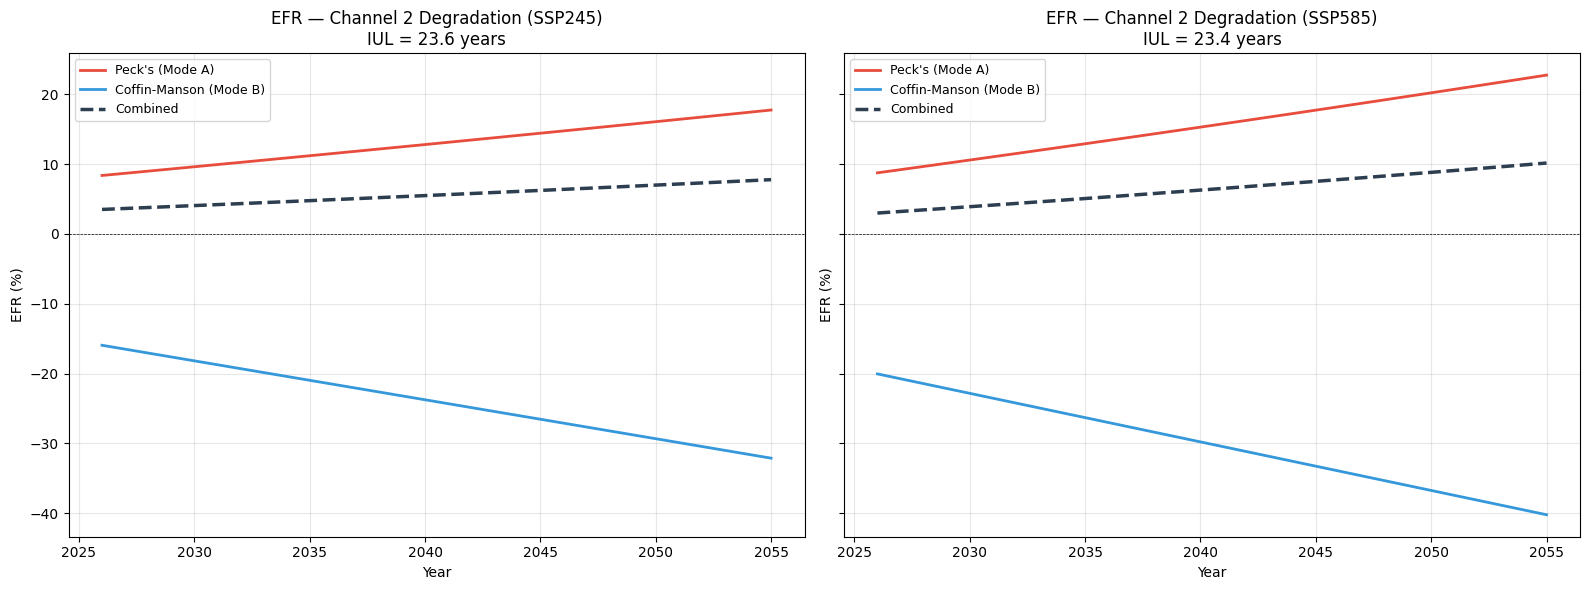

Saved: efr_timeline.png


In [6]:
# ── Visualization: EFR Timeline (Channel 2 Degradation) ──────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, ssp in zip(axes, SCENARIOS):
    sub = efr_annual_df[efr_annual_df["scenario"] == ssp]
    
    ax.plot(sub["year"], sub["efr_peck"] * 100, label="Peck's (Mode A)", 
            color="#e74c3c", linewidth=2)
    ax.plot(sub["year"], sub["efr_coffin"] * 100, label="Coffin-Manson (Mode B)", 
            color="#3498db", linewidth=2)
    ax.plot(sub["year"], sub["efr_combined"] * 100, label="Combined", 
            color="#2c3e50", linewidth=2.5, linestyle="--")
    
    # Mark IUL
    iul = iul_results[ssp]["iul"]
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    
    ax.set_title(f"EFR — Channel 2 Degradation ({ssp.upper()})\nIUL = {iul:.1f} years")
    ax.set_xlabel("Year")
    ax.set_ylabel("EFR (%)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(EFR_OUTPUT / "efr_timeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: efr_timeline.png")

In [7]:
# ── EFR Output Verification ──────────────────────────────────────────────────

checks_passed = 0
checks_total = 0

def check(name, condition):
    global checks_passed, checks_total
    checks_total += 1
    status = "✓" if condition else "✗"
    if condition:
        checks_passed += 1
    print(f"  {status} {name}")

print("── EFR Checks ──")
efr_read = pd.read_parquet(EFR_OUTPUT / "efr_annual.parquet")
check("EFR parquet round-trips", len(efr_read) == len(efr_annual_df))

efr_585 = efr_read[efr_read["scenario"] == "ssp585"]
check("Peck's EFR positive", efr_585["efr_peck"].mean() > 0)
check("Coffin-Manson EFR NEGATIVE", efr_585["efr_coffin"].mean() < 0)
check("Combined EFR positive (Peck's dominates)", efr_585["efr_combined"].mean() > 0)
check("Combined < Peck's (C-M offsets)", efr_585["efr_combined"].mean() < efr_585["efr_peck"].mean())

efr_j = json.load(open(EFR_OUTPUT / "efr_results.json"))
iul = efr_j["epoch_summary"]["ssp585"]["iul_years"]
check(f"IUL (SSP585) between 20-25 years (got {iul:.1f})", 20 <= iul <= 25)
check("Coffin-Manson mode is B", efr_j["models"]["coffin_manson"]["mode"] == "B")
check("Peck's mode is A", efr_j["models"]["peck"]["mode"] == "A")

print(f"\n── Result: {checks_passed}/{checks_total} checks passed ──")
print(f"\nOutput files:")
for f in sorted(EFR_OUTPUT.glob("*")):
    print(f"  {f.name:30s} {f.stat().st_size:>8,} bytes")

── EFR Checks ──
  ✓ EFR parquet round-trips
  ✓ Peck's EFR positive
  ✓ Coffin-Manson EFR NEGATIVE
  ✓ Combined EFR positive (Peck's dominates)
  ✓ Combined < Peck's (C-M offsets)
  ✓ IUL (SSP585) between 20-25 years (got 23.4)
  ✓ Coffin-Manson mode is B
  ✓ Peck's mode is A

── Result: 8/8 checks passed ──

Output files:
  efr_annual.parquet                7,506 bytes
  efr_results.json                  1,447 bytes
  efr_timeline.png                 94,299 bytes


## Summary — NB04b

**EFR (Channel 2):**
- Peck's (Mode A): temperature-driven aging acceleration
- Coffin-Manson (Mode B): direct freeze-thaw cycle counts — NEGATIVE at Hayhurst (benefit)
- Combined: Peck's dominates, C-M partially offsets
- IUL: asset life shortened by 1-2 years under SSP5-8.5

**Next:** Dashboard integration (add HCR + EFR tabs to Streamlit)